# 05.30 - Learning Curves & Model Diagnostics

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Is your model underfitting or overfitting? Learning curves diagnose the problem.

## 2. Why Does This Matter?

Without diagnostics, you waste time tuning the wrong thing. Curves tell you exactly what to do.

## 3. Prerequisites

- 05.01: ML fundamentals

## 4. Learning Objectives

- Generate and interpret learning curves
- Diagnose bias vs variance
- Decide what to do next (more data, more features, etc.)

## 5. Mental Model

High bias (underfitting): both train and val scores are low.
High variance (overfitting): train is high, val is low.
Good fit: both converge to high score.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Generate Learning Curves

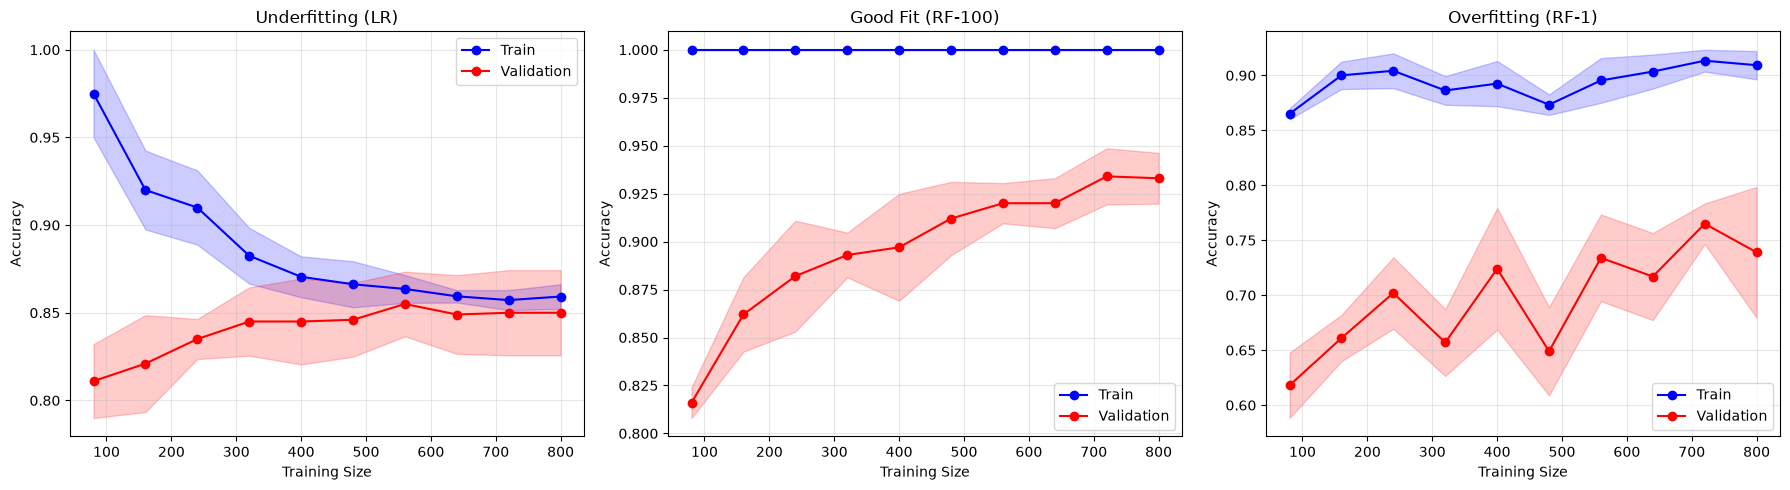

In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Underfitting (LR)", Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())])),
    ("Good Fit (RF-100)", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Overfitting (RF-1)", RandomForestClassifier(n_estimators=1, random_state=42))
]

for ax, (name, model) in zip(axes, models):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "b-o", label="Train")
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color="b")
    ax.plot(train_sizes, val_scores.mean(axis=1), "r-o", label="Validation")
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color="r")
    ax.set_title(name)
    ax.set_xlabel("Training Size")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Interpretation Guide

In [3]:
print("INTERPRETATION GUIDE:")
print("")
print("Underfitting (High Bias):")
print("  - Both curves are low")
print("  - Gap is small")
print("  - Fix: more features, complex model, reduce regularization")
print("")
print("Overfitting (High Variance):")
print("  - Train is high, validation is low")
print("  - Large gap between curves")
print("  - Fix: more data, simpler model, regularization, feature selection")
print("")
print("Good Fit:")
print("  - Both curves are high")
print("  - Small gap")
print("  - Converge as data increases")

INTERPRETATION GUIDE:

Underfitting (High Bias):
  - Both curves are low
  - Gap is small
  - Fix: more features, complex model, reduce regularization

Overfitting (High Variance):
  - Train is high, validation is low
  - Large gap between curves
  - Fix: more data, simpler model, regularization, feature selection

Good Fit:
  - Both curves are high
  - Small gap
  - Converge as data increases


## 8. Validation Curves

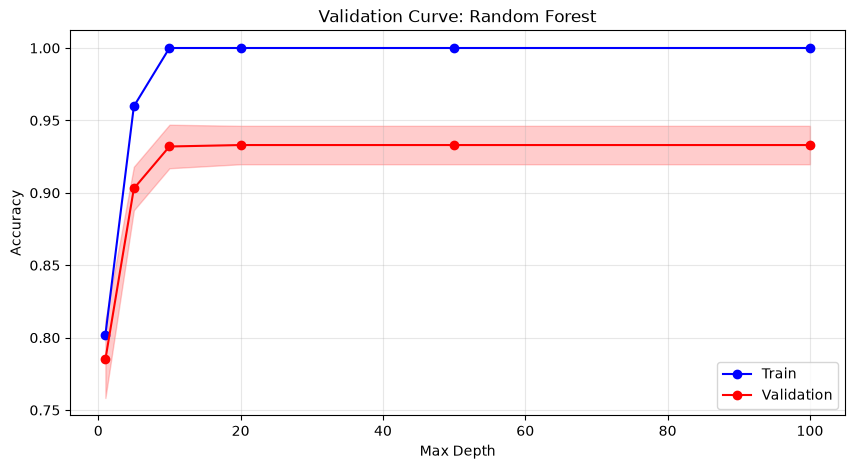

In [4]:
from sklearn.model_selection import validation_curve

param_range = [1, 5, 10, 20, 50, 100]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X, y,
    param_name="max_depth", param_range=param_range, cv=5
)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_scores.mean(axis=1), "b-o", label="Train")
plt.plot(param_range, val_scores.mean(axis=1), "r-o", label="Validation")
plt.fill_between(param_range, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color="r")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve: Random Forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("validation_curve.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. Decision Flowchart

1. Low train AND val score -> Underfitting -> Add features / complex model
2. High train, low val -> Overfitting -> More data / regularization / simpler model
3. Both high, small gap -> Good fit
4. Both high, large gap -> Slight overfitting -> Regularize

## 10. Coding Exercises

### Exercise 1: Diagnose a Model
Given a model, generate learning curves and diagnose.

### Exercise 2: Compare Architectures
Compare learning curves for different model complexities.

In [5]:
# EXERCISE 1: Diagnose
print("Exercise: Generate learning curves and diagnose.")

Exercise: Generate learning curves and diagnose.


In [6]:
# EXERCISE 2: Compare architectures
print("Exercise: Compare LR vs RF vs SVM learning curves.")

Exercise: Compare LR vs RF vs SVM learning curves.


## 11. Closed-Book Recall

1. What does a large gap between train and val curves indicate?
2. What does it mean when both curves are low?
3. When should you collect more data?

## 12. Teach-Back Questions

Explain learning curves to a product manager. How to use them for model selection.

## 13. Summary

Learning curves diagnose bias vs variance. Underfitting: both low. Overfitting: large gap. Use validation curves for hyperparameter tuning. Decision flowchart guides next steps.

## 14. Further Experiment

1. Try on a real dataset.
2. Plot learning curves for neural networks.
3. Create an automated diagnostic report.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```